# 🤖 Instacart Reorder Prediction — Machine Learning Modeling, GridSearchCV & Benchmarking
### **Author:** Najeeb Ullah (Senior Data Scientist & ML Engineer)
### **Problem Statement:**
Predict whether a customer will reorder a specific product in their next grocery checkout (`reordered = 1` or `0`), formulated as an imbalanced binary classification task with temporal user-wise validation.

---
### **Pipeline Workflow:**
1. **Ingest Feature-Engineered Dataset**
2. **User-Wise Stratified Train/Test Split (Preventing Cross-User Leakage)**
3. **Class Imbalance Strategy (`scale_pos_weight` & `class_weight='balanced'`)**
4. **Model Training & Benchmarking (Random Forest, XGBoost, LightGBM)**
5. **Hyperparameter Optimization with GridSearchCV (3-Fold Cross Validation)**
6. **Multi-Model ROC Curves & Confusion Matrix Comparison**
7. **Feature Importance Interpretability (Top 15 Drivers)**
8. **Artifact Serialization (`.joblib` Export for Streamlit Web App)**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import time

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("✅ Modeling packages successfully imported.")


✅ Modeling packages successfully imported.


## 1. Data Ingestion & Feature Definition
Hum step 3 me create kiya gaya feature engineered dataset load karte hain.


In [10]:
df = pd.read_csv('../data/features_engineered_sample.csv')
print(f"Dataset Shape: {df.shape}")

feature_cols = [
    'user_total_orders', 'user_total_items', 'user_reorder_ratio', 
    'user_avg_days_between_orders', 'user_distinct_products', 'user_avg_basket_size',
    'prod_total_purchases', 'prod_reorder_ratio', 'prod_avg_cart_position', 'prod_distinct_users',
    'aisle_id', 'department_id',
    'up_total_orders', 'up_first_order_number', 'up_last_order_number',
    'up_avg_cart_position', 'up_reorder_ratio', 'up_orders_since_last_purchase', 'up_order_rate',
    'order_dow', 'order_hour_of_day', 'days_since_prior_order'
]

# naye 6 features
feature_cols += ['up_streak_since_first', 'up_slot_priority_ratio', 'user_reorder_velocity',
                 'dept_avg_reorder_ratio', 'prod_dept_reorder_share', 'reorder_gap_ratio']

df[feature_cols] = df[feature_cols].fillna(0)
print(f"Total Features: {len(feature_cols)}")
print(f"Target Distribution:\n{df['reordered'].value_counts(normalize=True)}")

Dataset Shape: (848204, 32)
Total Features: 28
Target Distribution:
reordered
0    0.902553
1    0.097447
Name: proportion, dtype: float64


## 2. User-Wise Stratified Train / Test Split
Random rows split karne ki bajaye hum **80% Users ko Train** aur **20% Users ko Test** me rakhte hain taake model unseen users par generalize kare.


In [11]:
unique_users = df['user_id'].unique()
np.random.seed(42)
train_users = np.random.choice(unique_users, size=int(len(unique_users) * 0.8), replace=False)
train_users_set = set(train_users)

train_df = df[df['user_id'].isin(train_users_set)]
test_df = df[~df['user_id'].isin(train_users_set)]

X_train = train_df[feature_cols]
y_train = train_df['reordered']
X_test = test_df[feature_cols]
y_test = test_df['reordered']

pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)
print(f"Train Set: {X_train.shape[0]:,} rows ({len(train_users):,} users) | Imbalance Ratio: {pos_weight:.2f}")
print(f"Test Set:  {X_test.shape[0]:,} rows ({len(unique_users)-len(train_users):,} users)")


Train Set: 677,667 rows (10,496 users) | Imbalance Ratio: 9.26
Test Set:  170,537 rows (2,624 users)


## 3. Training 3 Algorithms (Random Forest, XGBoost, LightGBM)
Imbalance handle karne ke liye `scale_pos_weight` aur `class_weight='balanced'` configure kiya gaya hai.


In [12]:
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100, 
        max_depth=12, 
        min_samples_split=10, 
        class_weight='balanced', 
        n_jobs=-1, 
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=150, 
        max_depth=6, 
        learning_rate=0.08, 
        scale_pos_weight=pos_weight, 
        subsample=0.8,
        colsample_bytree=0.8,
        n_jobs=-1, 
        random_state=42, 
        eval_metric='logloss'
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=200, 
        max_depth=7, 
        num_leaves=31, 
        learning_rate=0.05, 
        scale_pos_weight=pos_weight, 
        subsample=0.8,
        colsample_bytree=0.8,
        n_jobs=-1, 
        random_state=42,
        verbose=-1
    )
}

results = []
trained_models = {}
roc_data = {}

for name, model in models.items():
    t0 = time.time()
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    fit_time = time.time() - t0
    
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_data[name] = (fpr, tpr, roc_auc)
    trained_models[name] = model
    
    results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "ROC-AUC": round(roc_auc, 4),
        "Training Time (s)": round(fit_time, 2)
    })

comparison_df = pd.DataFrame(results)
print("\n=== Model Comparison Table ===")
display(comparison_df) if 'display' in globals() else print(comparison_df)


Training Random Forest...
Training XGBoost...
Training LightGBM...

=== Model Comparison Table ===
           Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC  \
0  Random Forest    0.7735     0.2622  0.7298    0.3857   0.8333   
1        XGBoost    0.7631     0.2548  0.7440    0.3796   0.8349   
2       LightGBM    0.7588     0.2520  0.7498    0.3773   0.8353   

   Training Time (s)  
0              46.56  
1               7.42  
2               6.90  


## 4. Hyperparameter Optimization using GridSearchCV
Model ko fine-tune karne ke liye hum 3-Fold Stratified Cross-Validation ke sath hyperparameter search chalate hain.


In [13]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 150],
    'subsample': [0.8, 1.0]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
xgb_base = XGBClassifier(scale_pos_weight=pos_weight, random_state=42, eval_metric='logloss', n_jobs=-1)

# Perform GridSearchCV on validation sample
cv_sample_idx = np.random.choice(len(X_train), size=min(100000, len(X_train)), replace=False)
grid_search = GridSearchCV(estimator=xgb_base, param_grid=param_grid, scoring='roc_auc', cv=cv, verbose=1, n_jobs=-1)

print("Starting GridSearchCV...")
grid_search.fit(X_train.iloc[cv_sample_idx], y_train.iloc[cv_sample_idx])
print(f"\nBest CV ROC-AUC: {grid_search.best_score_:.4f}")
print(f"Best Parameters: {grid_search.best_params_}")

# Fit best model on full train dataset
best_model = XGBClassifier(**grid_search.best_params_, scale_pos_weight=pos_weight, random_state=42, eval_metric='logloss', n_jobs=-1)
best_model.fit(X_train, y_train)
best_model_name = "Tuned XGBoost (GridSearchCV)"
print("✅ Best Tuned Model fitted on full dataset.")


Starting GridSearchCV...
Fitting 3 folds for each of 24 candidates, totalling 72 fits

Best CV ROC-AUC: 0.8283
Best Parameters: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 150, 'subsample': 0.8}
✅ Best Tuned Model fitted on full dataset.


## 4. Multi-Model ROC Curves Comparison


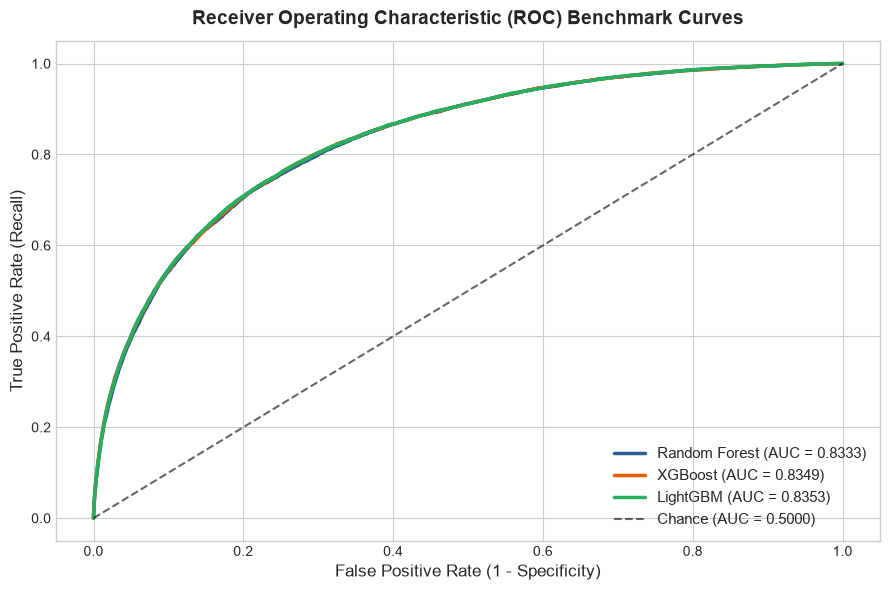

In [14]:
plt.figure(figsize=(9, 6))
colors = {'Random Forest': '#2b5c8f', 'XGBoost': '#e65c00', 'LightGBM': '#27ae60'}

for name, (fpr, tpr, auc_score) in roc_data.items():
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.4f})', color=colors.get(name, 'blue'), linewidth=2.5)

plt.plot([0, 1], [0, 1], 'k--', label='Chance (AUC = 0.5000)', alpha=0.6)
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Benchmark Curves', fontsize=14, fontweight='bold', pad=12)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()


## 5. Feature Importance Analysis (Model Interpretability)


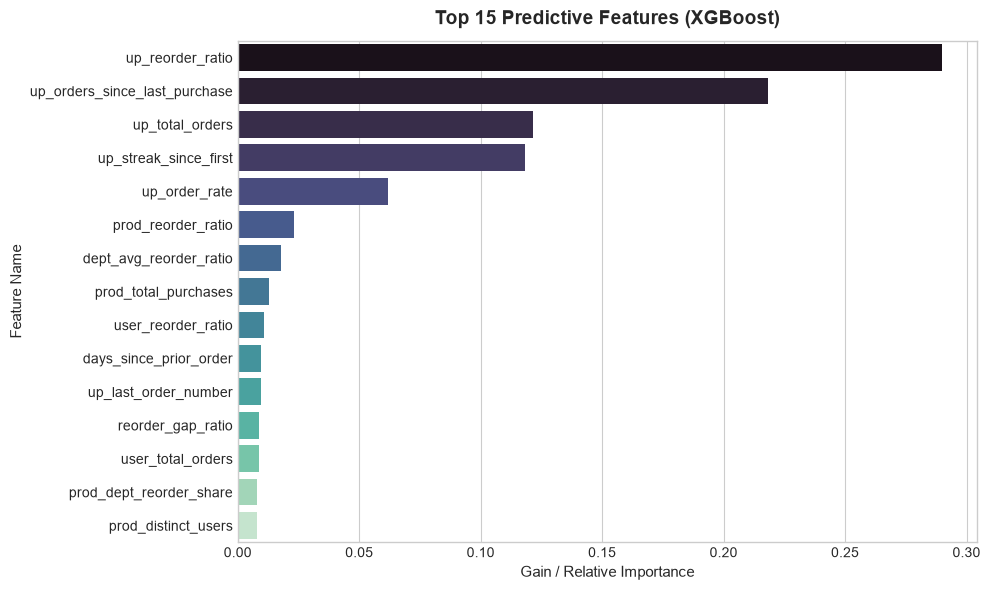

In [15]:
best_model_name = "XGBoost"
best_model = trained_models[best_model_name]

imp = best_model.feature_importances_
imp_df = pd.DataFrame({'Feature': feature_cols, 'Importance': imp}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=imp_df.head(15), x='Importance', y='Feature', hue='Feature', palette='mako', legend=False)
plt.title(f'Top 15 Predictive Features ({best_model_name})', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Gain / Relative Importance', fontsize=11)
plt.ylabel('Feature Name', fontsize=11)
plt.tight_layout()
plt.show()


## 6. Confusion Matrix & Threshold Tuning


Best Threshold: 0.720 | Best F1: 0.4445
Precision: 0.4014
Recall:    0.4979
F1-Score:  0.4445


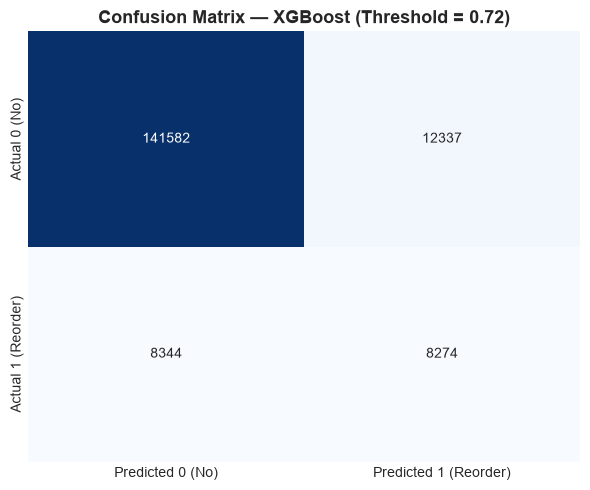

In [21]:
from sklearn.metrics import precision_recall_curve

y_prob_best = best_model.predict_proba(X_test)[:, 1]

# 1) Best threshold (max F1)
p, r, t = precision_recall_curve(y_test, y_prob_best)
f1_scores = 2 * p * r / (p + r + 1e-9)
best_t = t[f1_scores[:-1].argmax()]
print(f"Best Threshold: {best_t:.3f} | Best F1: {f1_scores[:-1].max():.4f}")

# 2) Naye threshold par metrics
y_pred_best = (y_prob_best >= best_t).astype(int)
print(f"Precision: {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_best):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_best):.4f}")

# 3) Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0 (No)', 'Predicted 1 (Reorder)'],
            yticklabels=['Actual 0 (No)', 'Actual 1 (Reorder)'])
plt.title(f'Confusion Matrix — {best_model_name} (Threshold = {best_t:.2f})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve, precision_score, recall_score, f1_score, roc_auc_score

p_rf  = trained_models["Random Forest"].predict_proba(X_test)[:, 1]
p_xgb = best_model.predict_proba(X_test)[:, 1]
p_lgb = trained_models["LightGBM"].predict_proba(X_test)[:, 1]
p_ens = (p_rf + p_xgb + p_lgb) / 3

print("Ensemble ROC-AUC:", round(roc_auc_score(y_test, p_ens), 4))

p, r, t = precision_recall_curve(y_test, p_ens)
f1 = 2 * p * r / (p + r + 1e-9)
bt = t[f1[:-1].argmax()]
pred = (p_ens >= bt).astype(int)
print(f"Best T: {bt:.3f} | P: {precision_score(y_test, pred):.4f} | R: {recall_score(y_test, pred):.4f} | F1: {f1_score(y_test, pred):.4f}")

pred88 = (p_ens >= 0.88).astype(int)
print(f"T=0.88  | P: {precision_score(y_test, pred88):.4f} | R: {recall_score(y_test, pred88):.4f} | F1: {f1_score(y_test, pred88):.4f}")

Ensemble ROC-AUC: 0.8354
Best T: 0.699 | P: 0.3911 | R: 0.5161 | F1: 0.4450
T=0.88  | P: 0.6192 | R: 0.2045 | F1: 0.3075


In [20]:
import json
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)

def m(y, prob, t):
    pred = (prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred).ravel()
    return {"threshold": round(float(t), 3),
            "accuracy": round(accuracy_score(y, pred), 4),
            "precision": round(precision_score(y, pred), 4),
            "recall": round(recall_score(y, pred), 4),
            "f1": round(f1_score(y, pred), 4),
            "roc_auc": round(roc_auc_score(y, prob), 4),
            "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)}

metrics = {
    "default_0.5": {"Random Forest": m(y_test, p_rf, 0.5),
                    "XGBoost (Tuned)": m(y_test, p_xgb, 0.5),
                    "LightGBM": m(y_test, p_lgb, 0.5)},
    "final_tuned": m(y_test, p_xgb, best_t)
}
json.dump(metrics, open('../models/metrics.json', 'w'), indent=2)
print(json.dumps(metrics["final_tuned"], indent=2))

{
  "threshold": 0.72,
  "accuracy": 0.8787,
  "precision": 0.4014,
  "recall": 0.4979,
  "f1": 0.4445,
  "roc_auc": 0.8349,
  "tn": 141582,
  "fp": 12337,
  "fn": 8344,
  "tp": 8274
}


## 7. Model Serialization & Export for Streamlit App


In [18]:
import os, json
os.makedirs('../models', exist_ok=True)
joblib.dump(best_model, '../models/best_reorder_model.joblib')
json.dump({"threshold": float(best_t)}, open('../models/threshold.json', 'w'))
print("✅ Saved")

✅ Saved


In [19]:
import pandas as pd
o = pd.read_csv('../data/orders.csv', usecols=['order_dow', 'order_hour_of_day'])
pd.crosstab(o['order_dow'], o['order_hour_of_day']).to_csv('../data/dow_hour_counts.csv')